In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 11

In [2]:
df = pd.read_csv("../data/cleaned_loans.csv")

In [3]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,revol_util,revol_bal,open_acc,total_acc,pub_rec,earliest_cr_line,issue_d,addr_state,loan_status,fico
0,3600.0,36.0,13.99,123.03,C,C4,-1.0,MORTGAGE,55000.0,Not Verified,...,29.7,2765.0,7.0,13.0,0.0,2003-08-01,2015-12-01,PA,Fully Paid,677.0
1,24700.0,36.0,11.99,820.28,C,C1,-1.0,MORTGAGE,65000.0,Not Verified,...,19.2,21470.0,22.0,38.0,0.0,1999-12-01,2015-12-01,SD,Fully Paid,717.0
2,20000.0,60.0,10.78,432.66,B,B4,-1.0,MORTGAGE,63000.0,Not Verified,...,56.2,7869.0,6.0,18.0,0.0,2000-08-01,2015-12-01,IL,Fully Paid,697.0
3,10400.0,60.0,22.45,289.91,F,F1,3.0,MORTGAGE,104433.0,Source Verified,...,64.5,21929.0,12.0,35.0,0.0,1998-06-01,2015-12-01,PA,Fully Paid,697.0
4,11950.0,36.0,13.44,405.18,C,C3,4.0,RENT,34000.0,Source Verified,...,68.4,8822.0,5.0,6.0,0.0,1987-10-01,2015-12-01,GA,Fully Paid,692.0


In [4]:
df.shape

(1345350, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1345350 entries, 0 to 1345349
Data columns (total 23 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   loan_amnt            1345350 non-null  float64
 1   term                 1345350 non-null  float64
 2   int_rate             1345350 non-null  float64
 3   installment          1345350 non-null  float64
 4   grade                1345350 non-null  str    
 5   sub_grade            1345350 non-null  str    
 6   emp_length           1345350 non-null  float64
 7   home_ownership       1345350 non-null  str    
 8   annual_inc           1345350 non-null  float64
 9   verification_status  1345350 non-null  str    
 10  purpose              1345350 non-null  str    
 11  dti                  1345350 non-null  float64
 12  delinq_2yrs          1345350 non-null  float64
 13  revol_util           1345350 non-null  float64
 14  revol_bal            1345350 non-null  float64
 15  open_acc 

### Business Question 1
#### What is the overall default rate?

This tells us how healthy the portfolio is.

In [6]:
# Create binary target variable
df["default"] = df["loan_status"].apply(
    lambda x: 0 if x == "Fully Paid" else 1
)

df[["loan_status", "default"]].head()

,loan_status,default
0,Fully Paid,0
1,Fully Paid,0
2,Fully Paid,0
3,Fully Paid,0
4,Fully Paid,0


In [7]:
default_rate = df["default"].mean() * 100

print(f"Overall Default Rate: {default_rate:.2f}%")

Overall Default Rate: 19.96%


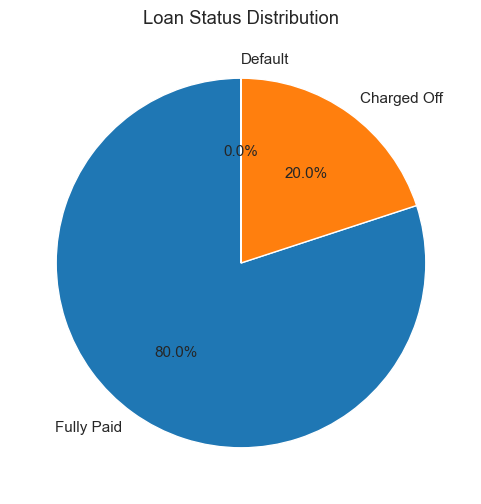

In [8]:
status = df["loan_status"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    status.values,
    labels=status.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Loan Status Distribution")

plt.show()

Business Insight
* Most loans are successfully repaid.
* Approximately X% of loans resulted in default or charge-off.
* Credit risk management remains a key business priority.

### Business Question 2
#### Which loan grades have the highest default rates?

In [9]:
grade = (df.groupby("grade").agg(Loans=("default","count"),DefaultRate=("default","mean"))
.reset_index())

grade["DefaultRate"] *=100

grade

,grade,Loans,DefaultRate
0,A,235095,6.042664
1,B,392748,13.386701
2,C,381694,22.441275
3,D,200966,30.386732
4,E,93656,38.482318
5,F,32059,45.204155
6,G,9132,49.934297


/var/folders/wy/pyd6gfbj0rn5k7yr6hcsygdw0000gn/T/ipykernel_86993/2291005531.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


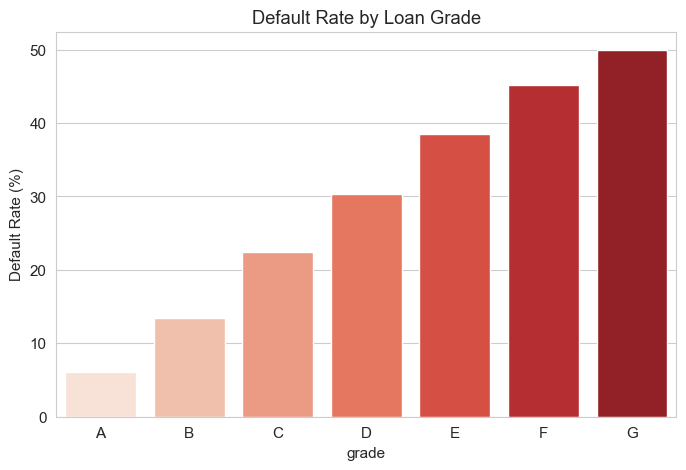

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(

data=grade,

x="grade",

y="DefaultRate",

palette="Reds"

)

plt.ylabel("Default Rate (%)")

plt.title("Default Rate by Loan Grade")

plt.show()

Business Insight
* Default rates increase steadily from Grade A to Grade G.
* Lower-grade loans require stricter underwriting or higher pricing.

### Business Question 3
#### Which loan purposes are the riskiest?

In [11]:
purpose = (

df

.groupby("purpose")

.agg(

Loans=("default","count"),

DefaultRate=("default","mean")

)

.reset_index()

)

purpose["DefaultRate"] *=100

purpose = purpose.sort_values(

"DefaultRate",

ascending=False

)

/var/folders/wy/pyd6gfbj0rn5k7yr6hcsygdw0000gn/T/ipykernel_86993/4187602280.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


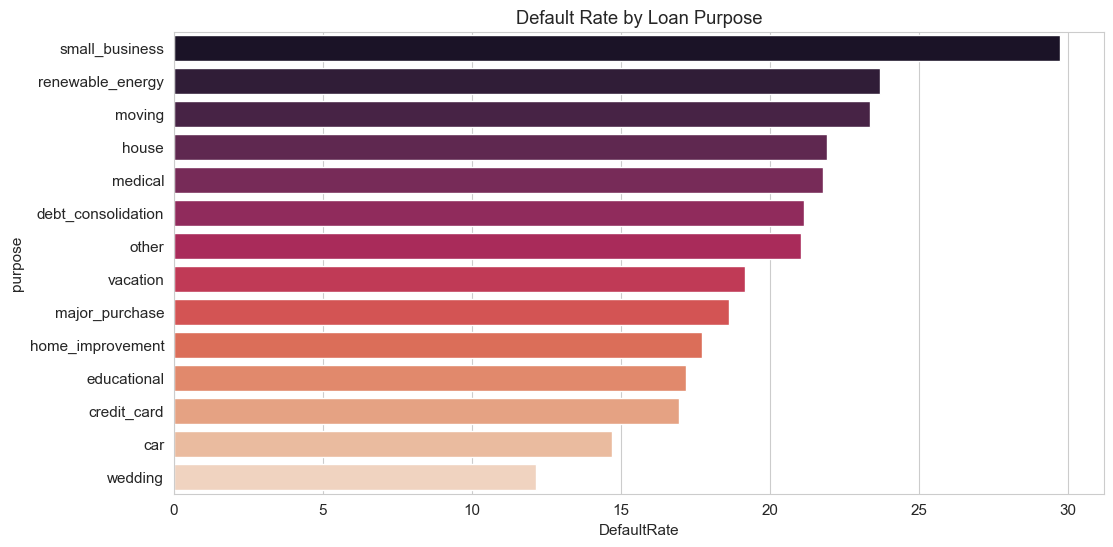

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(

data=purpose,

x="DefaultRate",

y="purpose",

palette="rocket"

)

plt.title("Default Rate by Loan Purpose")

plt.show()

Business Insight
* Certain loan purposes exhibit significantly higher default rates.
* Purpose should be considered when assessing borrower risk.

### Business Question 4
#### Do higher interest rates correspond to higher defaults?

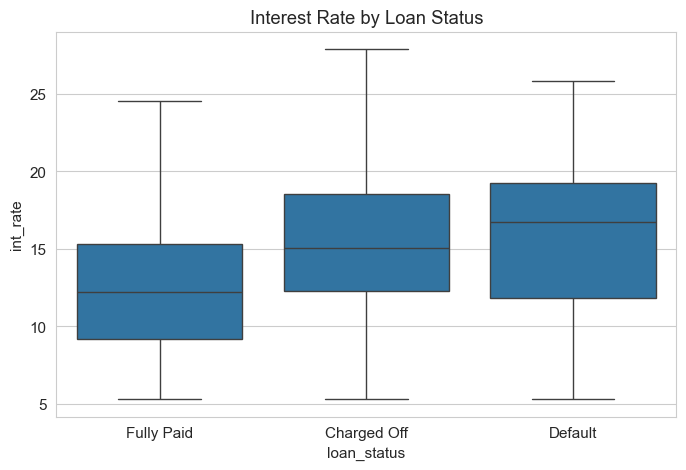

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="loan_status",

y="int_rate",

showfliers=False

)

plt.title("Interest Rate by Loan Status")

plt.show()

Business Insight
* Borrowers who default generally receive higher interest rates.
* Interest rate reflects the lender's perceived risk at origination.

### Business Question 5
#### Does annual income reduce default risk?

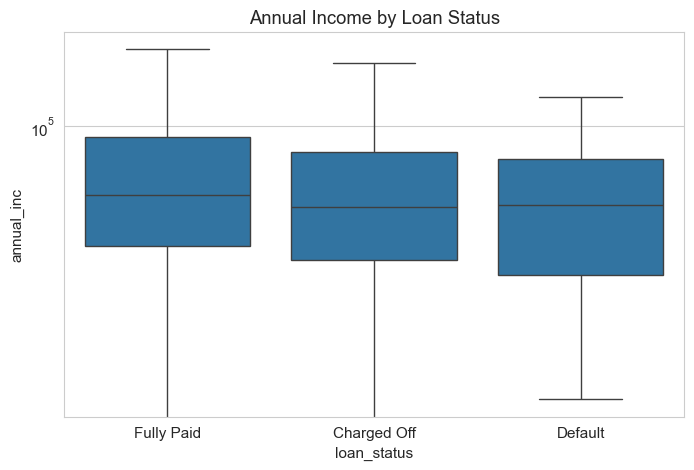

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="loan_status",

y="annual_inc",

showfliers=False

)

plt.yscale("log")

plt.title("Annual Income by Loan Status")

plt.show()

Business Insight
* Higher-income borrowers tend to default less frequently.
* Income should not be used alone but is an important predictor of repayment capacity.

### Business Question 6
#### Does Debt-to-Income (DTI) influence default?

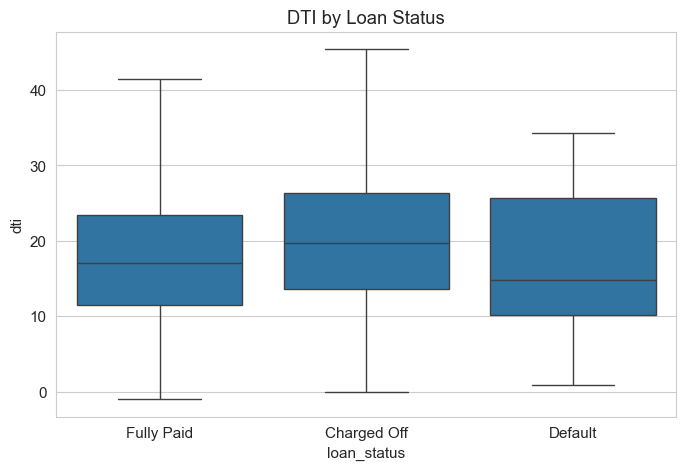

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="loan_status",

y="dti",

showfliers=False

)

plt.title("DTI by Loan Status")

plt.show()

Business Insight
* Borrowers with higher DTI values are more likely to default.
* High existing debt reduces repayment capacity.

### Business Question 7
#### Does FICO score matter?

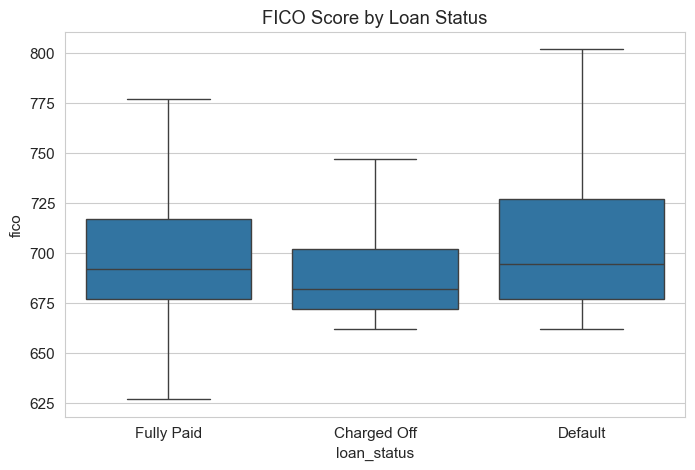

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="loan_status",

y="fico",

showfliers=False

)

plt.title("FICO Score by Loan Status")

plt.show()

Business Insight
* Defaulters generally have lower FICO scores.
* Credit score remains one of the strongest indicators of borrower quality.

### Business Question 8
#### Which states have the highest default rate?

In [17]:
state = (

df

.groupby("addr_state")

.agg(

Loans=("default","count"),

DefaultRate=("default","mean")

)

.reset_index()

)

state["DefaultRate"] *=100

state = state[state["Loans"]>100]

state = state.sort_values(

"DefaultRate",

ascending=False

).head(15)

/var/folders/wy/pyd6gfbj0rn5k7yr6hcsygdw0000gn/T/ipykernel_86993/289792870.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


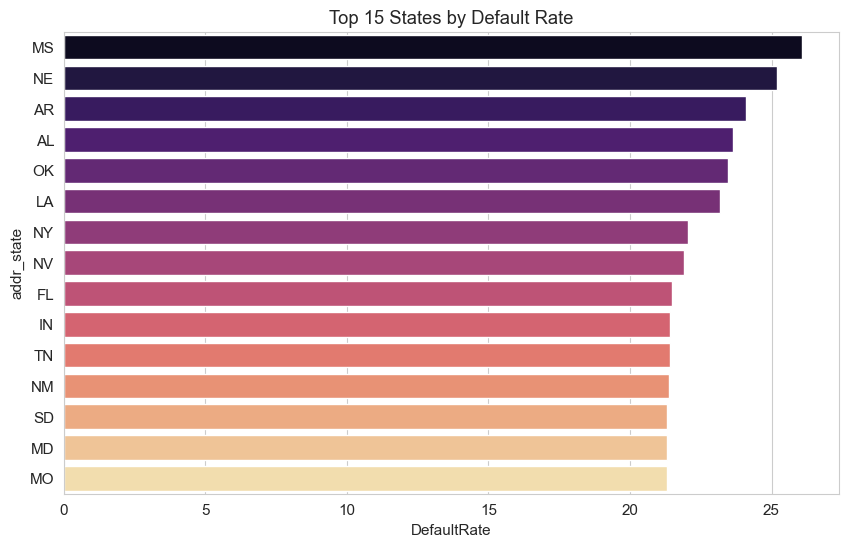

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(

data=state,

x="DefaultRate",

y="addr_state",

palette="magma"

)

plt.title("Top 15 States by Default Rate")

plt.show()

Business Insight
* Geographic variation in default rates can help identify regional lending risks and support targeted credit strategies.

### Business Question 9
#### Does employment length affect repayment?

In [19]:
employment = (

df

.groupby("emp_length")

.agg(

Loans=("default","count"),

DefaultRate=("default","mean")

)

.reset_index()

)

employment["DefaultRate"] *=100

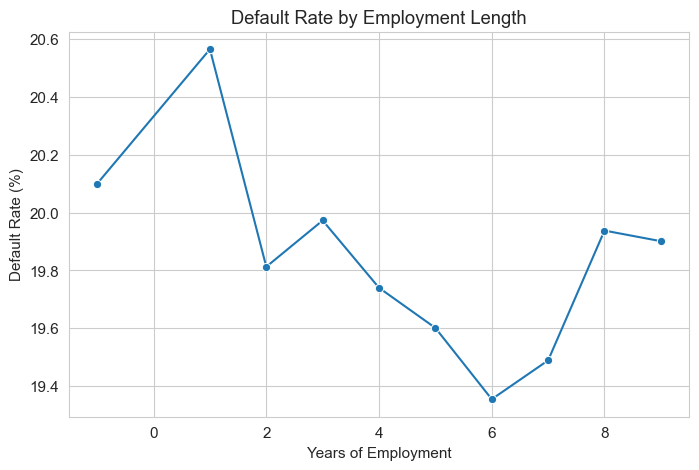

In [20]:
plt.figure(figsize=(8,5))

sns.lineplot(

data=employment,

x="emp_length",

y="DefaultRate",

marker="o"

)

plt.title("Default Rate by Employment Length")

plt.xlabel("Years of Employment")

plt.ylabel("Default Rate (%)")

plt.show()

Business Insight
* Borrowers with longer employment histories generally exhibit lower default rates, suggesting greater financial stability.

### Business Question 10
#### Does revolving credit utilization impact default?

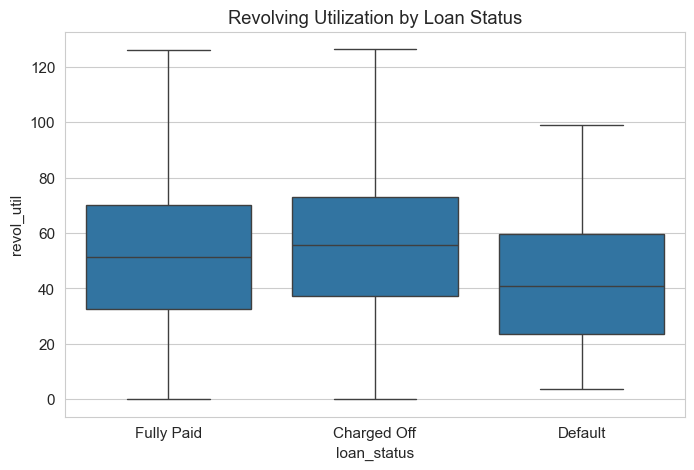

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="loan_status",

y="revol_util",

showfliers=False

)

plt.title("Revolving Utilization by Loan Status")

plt.show()

Business Insight
* High credit utilization is associated with increased default risk and should be monitored during underwriting.

### Business Question 11
#### How are loan amounts distributed?

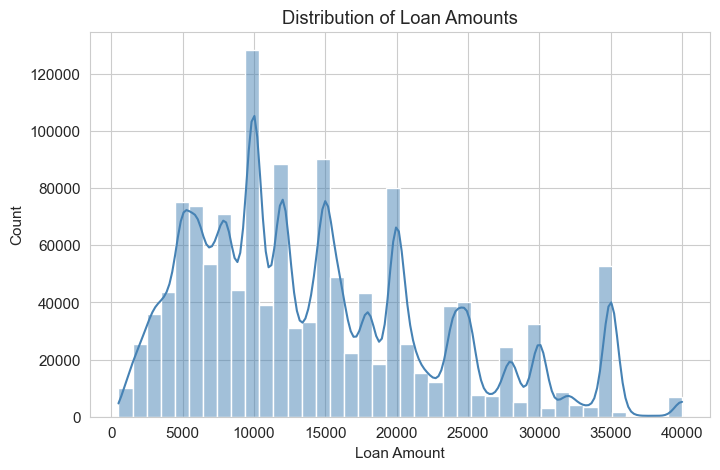

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(

df["loan_amnt"],

bins=40,

kde=True,

color="steelblue"

)

plt.title("Distribution of Loan Amounts")

plt.xlabel("Loan Amount")

plt.show()

Business Insight
* The portfolio is concentrated in smaller and medium-sized loans, with relatively few high-value exposures.

### Business Question 12
#### Which numerical variables are most correlated?

In [23]:
numeric_cols = [
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "installment",
    "dti",
    "fico",
    "revol_util",
    "revol_bal",
    "default"
]

corr = df[numeric_cols].corr()

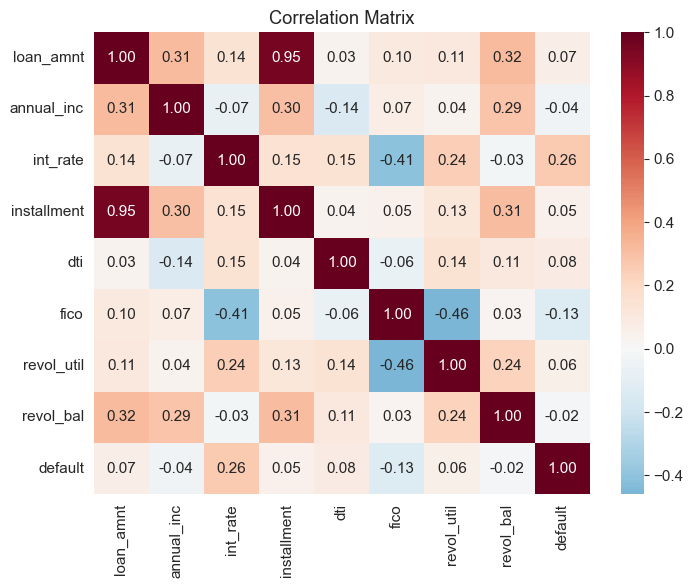

In [24]:
plt.figure(figsize=(8,6))

sns.heatmap(

corr,

annot=True,

fmt=".2f",

cmap="RdBu_r",

center=0

)

plt.title("Correlation Matrix")

plt.show()

Business Insight
* Correlation analysis helps identify relationships among financial variables and highlights which features may be influential in predicting default.